# Trabajo en Equipo (A2)

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1. Importe el archivo `BMI Dataset.csv` como un DataFrame.

In [4]:
raw_data = pd.read_csv("../Datos/BMI Dataset.csv", sep = ";")
# raw_data.columns = [f"column_{i+1}" for i in range(raw_data.shape[1])]
# raw_data = raw_data.drop(columns = "bmi")
# raw_data["sex"] = np.random.choice(a = ["male", "female"], size = len(raw_data), p = [0.456, 1-0.456])
# raw_data.to_csv("../Datos/BMI Dataset.csv", sep = ";")

In [ ]:
# nombres = raw_data.columns
# raw_data = raw_data.rename(columns={"column_8": "height_m", "column_9": "weight_kg", "column_7": "steps"})
# raw_data["bmi"] = raw_data["weight_kg"]/raw_data["height_m"]**2
# raw_data = raw_data.loc[~raw_data["bmi"].between(0, 18)]
# raw_data = raw_data.loc[~raw_data["steps"].between(0, 2100)]
# raw_data = raw_data.loc[~(raw_data["steps"].between(12000, 21000) & raw_data["bmi"].between(26, 48))]
# raw_data = raw_data.drop(columns = "bmi")
# raw_data.columns = nombres
# raw_data.to_csv("../Datos/BMI Dataset.csv", sep = ";", index = False)

2. Muestre las primeras 5 filas del DataFrame.

In [5]:
raw_data.head(5)

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,column_6,column_7,column_8,column_9,column_10
0,0,0,0,0,0,male,8681.25,1.868751,100.396145,44
1,1,1,1,1,1,female,8700.00,1.726109,85.654612,18
2,2,2,2,2,2,female,8718.75,1.612302,74.732127,32
3,3,3,3,3,3,female,9393.75,1.726220,85.665608,29
4,4,4,4,4,4,female,9412.50,1.570429,70.900725,45


3. Muestre las últimas 7 filas del DataFrame

In [6]:
raw_data.tail(7)

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,column_6,column_7,column_8,column_9,column_10
34598,34598,34598,34598,34598,34598,male,13987.50,1.602591,46.248555,40
34599,34599,34599,34599,34599,34599,female,14006.25,1.911319,65.783793,36
34600,34600,34600,34600,34600,34600,male,14025.00,1.710586,52.691721,31
34601,34601,34601,34601,34601,34601,male,14043.75,1.721932,53.393042,44
34602,34602,34602,34602,34602,34602,male,14062.50,1.774445,56.699288,18
34603,34603,34603,34603,34603,34603,male,14081.25,1.797845,58.204565,31
34604,34604,34604,34604,34604,34604,female,14100.00,1.795278,58.038485,42


4. Elimine todas las columnas donde el valor de la celda sea igual al indice (`df.index`) del DataFrame.

In [7]:
for col in raw_data.columns:
    if (raw_data[col] == raw_data.index).all():
        raw_data.drop(columns=col, inplace=True)

In [8]:
raw_data

,column_6,column_7,column_8,column_9,column_10
0,male,8681.25,1.868751,100.396145,44
1,female,8700.00,1.726109,85.654612,18
2,female,8718.75,1.612302,74.732127,32
3,female,9393.75,1.726220,85.665608,29
4,female,9412.50,1.570429,70.900725,45
...,...,...,...,...,...
34600,male,14025.00,1.710586,52.691721,31
34601,male,14043.75,1.721932,53.393042,44
34602,male,14062.50,1.774445,56.699288,18
34603,male,14081.25,1.797845,58.204565,31


6. Utilice el método `.describe()` para ver las estadísticas descriptivas de cada variable. Revise cuál es el rango de cada variable.

In [9]:
raw_data.describe()

,column_7,column_8,column_9,column_10
count,34605.000000,34605.000000,34605.000000,34605.000000
mean,8474.350347,1.749962,74.205395,34.726398
std,2750.340633,0.144150,16.120333,9.570540
min,2681.250000,1.500003,40.566905,18.000000
25%,6731.250000,1.625212,62.406681,28.000000
50%,8437.500000,1.750348,72.564469,35.000000
75%,10387.500000,1.873822,86.084376,41.000000
max,14456.250000,1.999962,114.427166,72.000000


7. Si hizo todo correctamente le deberían quedar 5 columnas. Las columnas restantes son **edad, sexo, peso (kg), número de pasos de la persona en el último domingo, altura (mts)**. Usando el sentido común y la información del punto anterior, asignele a cada columna el nombre correcto.

In [10]:
raw_data.columns = ["sex", "steps", "height_m", "weight_kg", "age"]
raw_data.head()

,sex,steps,height_m,weight_kg,age
0,male,8681.25,1.868751,100.396145,44
1,female,8700.00,1.726109,85.654612,18
2,female,8718.75,1.612302,74.732127,32
3,female,9393.75,1.726220,85.665608,29
4,female,9412.50,1.570429,70.900725,45


8. Construya el Índice de Masa Corporal a partir de la información de la estatura y el peso.

In [11]:
raw_data["bmi"] = raw_data["weight_kg"]/raw_data["height_m"]**2
raw_data["bmi"].describe()

count    34605.000000
mean        24.067171
std          3.387239
min         18.007472
25%         21.276463
50%         24.993773
75%         26.917808
max         28.748443
Name: bmi, dtype: float64

9. De acuerdo a la siguiente tabla, construya una nueva variable categórica que tome el valor de **Infrapeso, Normal, Sobrepeso, Obeso**.


|     IMC     | Categoría |
|:-----------:|:---------:|
|    < 18.5   | Infrapeso |
| 18.5 - 24.9 |   Normal  |
|   25 - 30   | Sobrepeso |
|     > 30    |   Obeso   |

Para resolver este punto utilice la función `pd.cut()`


In [12]:
raw_data["categories"] = pd.cut(raw_data["bmi"], [-np.inf, 18.5, 25, 30, np.inf], labels = ["Infrapeso", "Normal", "Sobrepeso", "Obeso"])

10. Cuente cuántas personas hay en cada categoría. Muestre tanto el número de personas (conteo) como el porcentaje (proporción) correspondiente.

In [13]:
print(raw_data["categories"].value_counts())
print(raw_data["categories"].value_counts(normalize=True))

categories
Sobrepeso    17251
Normal       14449
Infrapeso     2905
Obeso            0
Name: count, dtype: int64
categories
Sobrepeso    0.498512
Normal       0.417541
Infrapeso    0.083947
Obeso        0.000000
Name: proportion, dtype: float64


11. Construya la proporción de categorías por sexo. Para hacer eso haga uso de un `groupby()` y construya la tabla en formato _long_. Es decir, sus columnas deben ser: sex, categories, count (pueden tener otros nombres.)

In [14]:
categories_sex = raw_data.groupby("sex")["categories"].value_counts().reset_index()
categories_sex

,sex,categories,count
0,female,Sobrepeso,9178
1,female,Normal,7864
2,female,Infrapeso,1532
3,female,Obeso,0
4,male,Sobrepeso,8073
5,male,Normal,6585
6,male,Infrapeso,1373
7,male,Obeso,0


12. Construya una gráfica de barras que compare la cantidad de personas en cada una de las categorías por sexo. Su eje X deben ser las categorías y su eje Y el conteo de personas. Toda la información de su gráfica debe estar en español. Esto incluye el nombre de los ejes, el título, la leyenda y demás componentes. 

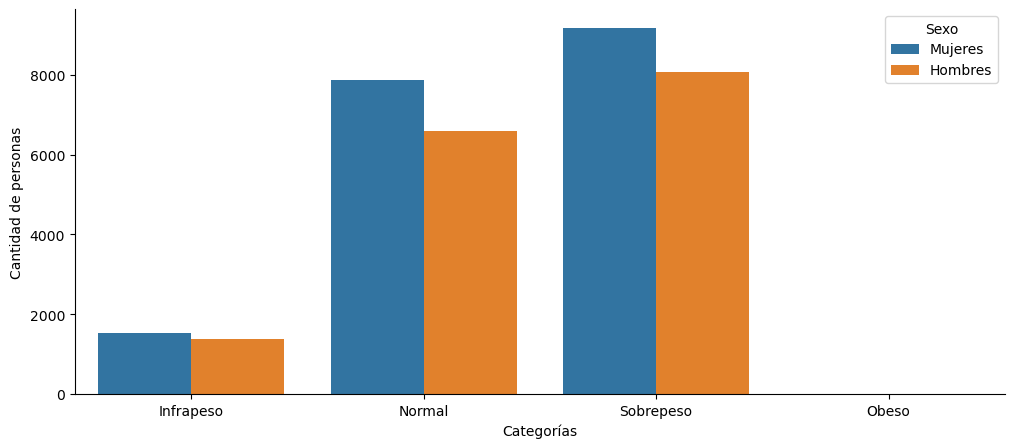

In [15]:
fig, ax = plt.subplots(figsize = (12, 5))
sns.despine()
sns.barplot(data = categories_sex, x = 'categories', y = "count", hue = "sex")
plt.xlabel("Categorías")
plt.ylabel("Cantidad de personas")
legend =plt.legend(title = "Sexo")
legend.get_texts()[0].set_text('Mujeres')
legend.get_texts()[1].set_text('Hombres')

13. Basándose en la gráfica anterior, Cree que se podría afirmar que las mujeres tienen más sobrepeso que los hombres? Para apoyar su respuesta, haga una gráfico de torta que compare el número de hombres contra el número de mujeres.

<Axes: ylabel='count'>

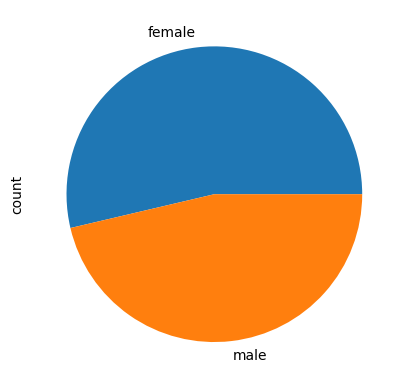

In [16]:
raw_data["sex"].value_counts().plot(kind="pie")

14. Para responder la pregunta anterior haga una prueba de hipótesis donde compare la media del IMC para las mujeres vs la media de los hombres. Siga los siguientes pasos para realizar la prueba T-Student:
- Divida su DataFrame en dos nuevos DataFrames llamados: `hombres` y `mujeres`.
- Realice el test de Levene usando la función `levene` del modulo `scipy.stats` para comprobar que la desviación estándar de cada grupo es homogénea. 
    ```python
    levene(hombres["bmi"], mujeres["bmi"])
    ```
    Investigue cuáles es la Hipótesis Nula y Alternativa de la prueba para concluir según el p-valor.
- Cree la variable `equal_var` basándose en el p-valor de la prueba de Levene. Si no puede rechazar la hipótesis nula para una significancia del 5% entonces `equal_var=True`. En caso de que pueda rechazar la hipótesis nula, `equal_var=False`.
- Ahora utilice la función `ttest_ind` del modulo `scipy.stats` para comparar el IMC del grupo de los hombres contra el grupo de las mujeres utilizando el parámetro `equal_var`. Concluya si hay evidencia estadística o no de que la media del IMC es diferente.

In [17]:
hombres = raw_data.loc[raw_data["sex"] == "male", ].reset_index(drop = True)
mujeres = raw_data.loc[raw_data["sex"] == "female", ].reset_index(drop = True)

In [18]:
from scipy.stats import levene
stat, p_levene = levene(hombres["bmi"], mujeres["bmi"])

# Aplicar prueba t con equal_var según Levene
equal_var = p_levene > 0.05
equal_var

True

In [19]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(hombres["bmi"], mujeres["bmi"], equal_var=equal_var)
print(f'Test t de Student: t = {t_stat:.3f}, p = {p_value:.3f}')

# Conclusión
alpha = 0.05
if p_value < alpha:
    print('Conclusión: Hay evidencia estadística de que las medias son diferentes.')
else:
    print('Conclusión: No hay evidencia estadística de diferencia en las medias.')

Test t de Student: t = 1.200, p = 0.230
Conclusión: No hay evidencia estadística de diferencia en las medias.


15. Calcule la correlación entre las variables edad, altura, peso, IMC, número de pasos. Puede utilizar el método `.corr()` sobre la base directamente.

In [20]:
correlaciones = raw_data.select_dtypes(include="number").corr()

16. Guarde el DataFrame pasado como `correlaciones` y cree un correlograma o _heatmap_ usando la función `sns.heatmap()`. Analice las correlaciones de las variables contra el IMC.

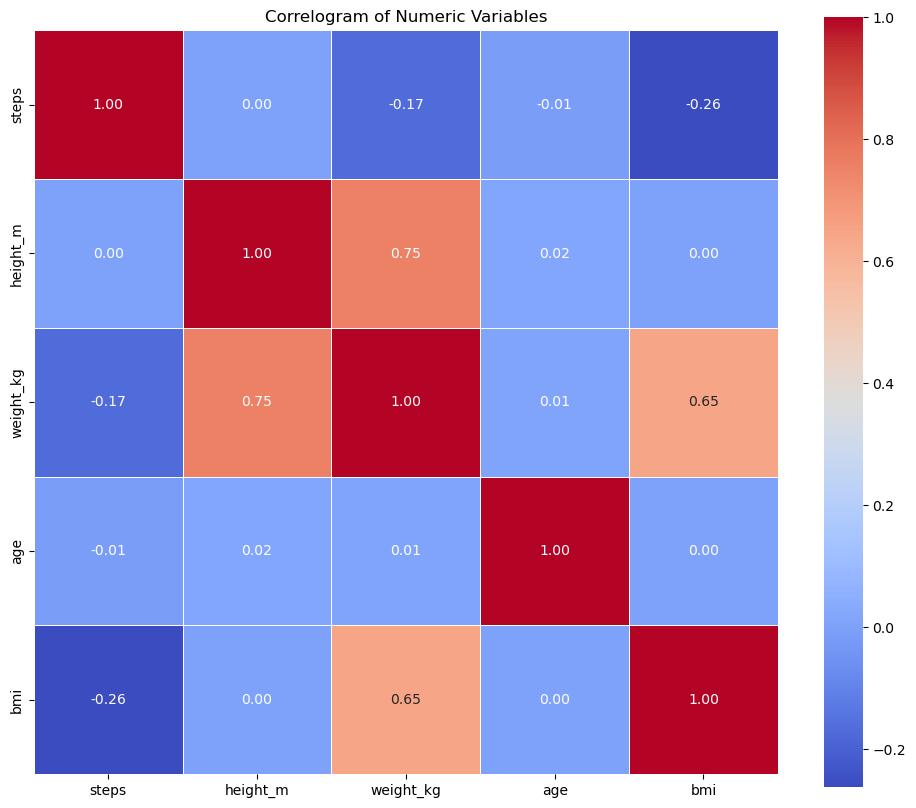

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlogram of Numeric Variables")
plt.show()

17. Exploración libre. Estudie la base de datos a profundidad en busca de alguna inconsistencia. Una vez termine su validación, siga al siguiente punto.

18. Para finalizar su análisis, construya un gráfico de dispersión entre el número de pasos (eje X) y el IMC (eje Y) donde el color de cada punto esté determinado por el sexo. El tamaño de cada punto debe ser **1** y el tamaño del lienzo **7x10**.

    Luego de analizar la gráfica, cree que el análisis realizado hasta el momento ha sido robusto?

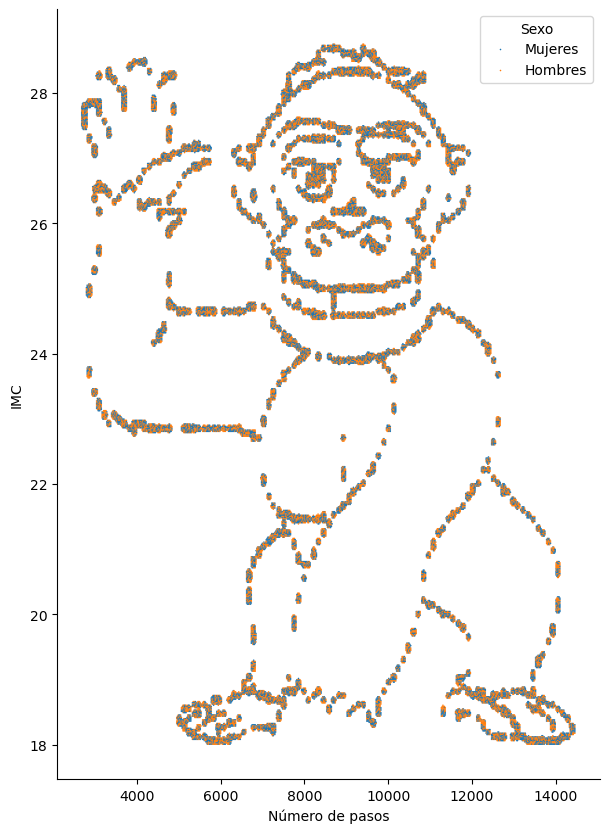

In [22]:
fig, ax = plt.subplots(figsize = (7, 10))
sns.despine()
sns.scatterplot(data = raw_data, x = 'steps', y = "bmi", hue = "sex", s=1, edgecolor=None, ax=ax)
plt.xlabel("Número de pasos")
plt.ylabel("IMC")
legend = plt.legend(title = "Sexo")
legend.get_texts()[0].set_text('Mujeres')
legend.get_texts()[1].set_text('Hombres')